# Roman Grism Dispersion Tutorial
## Single Star and Galaxy Dispersal on SCA 01

**Workshop Tutorial — Roman GRS PIT 2026**

This tutorial demonstrates how the Roman Space Telescope Wide Field Instrument (WFI) grism
disperses light across the detector. We'll simulate two types of sources:

| Source Type | Shape | Dispersion Model |
|-------------|---------|------------------|
| **Star** | Point source (PSF) | Wavelength-dependent PSFs deposited along spectral trace |
| **Galaxy** | Extended source (finite size, ~0.5 arcsec radius) | Jacobian-based morphology warping + PSF convolution |

**Prerequisites:** This notebook assumes PSF caches are available at `data/psf_cache/`.
If you need to generate them, run:

```bash
pixi run python scripts/generate_psf_caches.py --detectors WFI01 --orders 0 1
```

---
## Configuration

All key parameters are defined below.

**Key parameters to experiment with:**
- `SCA` — try different detector numbers (1–18) to see how traces vary
- `X_STAR` / `Y_STAR` — move the source around to see how traces shift
- `GAL_REFF_ARCSEC` — larger galaxies smear more across wavelengths
- `N_WAVELENGTH` — more wavelengths = smoother traces (but slower)

In [15]:
# ============================================================================
# IMPORTS
# ============================================================================

import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm, LogNorm
import jax.numpy as jnp

# Roman disperser modules
from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.galaxy_disperser as galaxy_disperser
import roman_disperser.psf_model as psf_model
from roman_disperser import demo_utils

# Visualization settings
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

project_root = Path("/Users/keith/astr/research/roman_disperser")

In [16]:
# PARAMETERS

# --- Detector ---
SCA = 1                      # SCA number (1–18)
DETECTOR = f'WFI{SCA:02d}'   # e.g., 'WFI01'

# --- Spectral orders ---
# Order 0 = zeroth order (uses distinct PSF from order 2)
# Order 1 = first order (primary dispersed spectrum, highest throughput)
# Order 2 = second order (uses same PSF as order 1)
ORDERS = ['0', '1', '2']

# --- Source positions ---
# Star/galaxy center in SCA pixel coordinates (FITS 1-indexed)
X_STAR = 2000.0
Y_STAR = 2000.0

# --- Galaxy properties ---
GAL_NPIX_NATIVE = 30         # Native pixels per side (3.3 arcsec at 0.11"/pix)
GAL_REFF_ARCSEC = 0.5        # Half-light radius (larger = more smeared)
OVERSAMPLE = 4               # PSF oversampling factor (must match cache)

# --- Wavelength grid ---
LAM_MIN = 0.9                # Minimum wavelength (microns)
LAM_MAX = 2.0                # Maximum wavelength (microns)
DLAM_ANGSTROMS = 2.0         # 2 Angstrom spacing
dlam_um = DLAM_ANGSTROMS / 1e4
N_WAVELENGTH = int((LAM_MAX - LAM_MIN) / dlam_um) + 1  # = 5501

# --- PSF cache ---
PSF_CACHE_DIR = 'data/psf_cache'

# --- Visualization ---
ASINH_GAMMA = 0.01           # Asinh stretch parameter
LOG_MIN_DB = -4              # LogNorm minimum in dB
ZOOM_PAD = 50                # Extra padding around zoomed regions (pixels)

print(f"Configuration:")
print(f"  Detector: {DETECTOR} (SCA {SCA})")
print(f"  Orders: {ORDERS}")
print(f"  Source position: ({X_STAR:.1f}, {Y_STAR:.1f}) SCA pixels")
print(f"  Galaxy: {GAL_NPIX_NATIVE}×{GAL_NPIX_NATIVE} native, r_eff={GAL_REFF_ARCSEC}\" at {OVERSAMPLE}× oversampling")
print(f"  Wavelength: {LAM_MIN}–{LAM_MAX} μm, {DLAM_ANGSTROMS}Å spacing → {N_WAVELENGTH} samples")

Configuration:
  Detector: WFI01 (SCA 1)
  Orders: ['0', '1', '2']
  Source position: (2000.0, 2000.0) SCA pixels
  Galaxy: 30×30 native, r_eff=0.5" at 4× oversampling
  Wavelength: 0.9–2.0 μm, 2.0Å spacing → 5501 samples


---
## 1. Loading the Optical Model

The **optical model** predicts where light from a given detector position lands
for each wavelength. It encodes:

- The detector geometry (pixel scale, plate scale, center position)
- The grism dispersion coefficients (curvature and inverse dispersion)
- Wavelength transform (linear or log)

The key function is `trace_beam()`, which takes (FPA position, wavelength) and
returns the dispersed position on the detector. We create an **optical payload**
per SCA per order — this is the minimal set of parameters needed for dispersion.

In [17]:
# Load optical model from YAML configuration
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"

model = RomanOpticalModel(config_file=str(config_path))
pixel_scale = model.detmod['pixel_scale']
print(f"Loaded optical model from {config_path.name}")
print(f"  Pixel scale: {pixel_scale} arcsec/pixel")
print(f"  Plate scale: {model.detmod['plate_scale']} arcsec/mm")
print(f"  SCA list: {model.sca_list}")
print(f"  Orders defined: {model.beam_coeffs.keys()}")

Loaded optical model from Roman_grism_OpticalModel_v0.8.yaml
  Pixel scale: 0.11 arcsec/pixel
  Plate scale: 100 arcsec/mm
  SCA list: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
  Orders defined: dict_keys(['1', '0', '2', 'm1'])


In [18]:
# Create optical payloads for each order on our SCA
# This extracts the minimal parameters needed for trace_beam() calculations
optical_payloads = {}
for order in ORDERS:
    optical_payloads[order] = omj.make_sca_payload(model, sca=SCA, order=order)
    print(f"  Created optical payload for SCA {SCA}, order {order}")

  Created optical payload for SCA 1, order 0
  Created optical payload for SCA 1, order 1
  Created optical payload for SCA 1, order 2


---
## 2. Loading PSF Caches

The **PSF model** provides wavelength-dependent Point Spread Functions computed
using [STPSF](https://stpsf.readthedocs.io) (Space Telescope PSF Simulator). Key facts:

- PSFs vary across the detector
- PSFs vary with wavelength
- We use **trilinear interpolation** on a spatial × wavelength grid to get
  the PSF at any position and wavelength
- PSFs are **4× oversampled** for accurate sub-pixel positioning

In [19]:
# Load PSF payloads from cache
# We only need PSFs for orders 0 and 1; order 2 reuses order 1
cache_dir = project_root / PSF_CACHE_DIR if PSF_CACHE_DIR else None

psf_payloads = {}
psf_orders_to_load = ['0', '1']

t0 = time.time()
for order in psf_orders_to_load:
    try:
        psf_payloads[order] = psf_model.get_or_make_psf_payload(
            detector=DETECTOR,
            order=order,
            cache_dir=str(cache_dir) if cache_dir else None,
            verbose=True,
        )
    except FileNotFoundError:
        print(f"\n⚠ No cached PSF for order {order} on {DETECTOR}")
        print(f"  To generate: pixi run python scripts/generate_psf_caches.py \\"
              f"--detectors {DETECTOR} --orders {order}")
        raise

# Order 2 reuses order 1 PSFs (same grism optical path)
psf_payloads['2'] = psf_payloads['1']
print(f"  Order 2: reusing Order 1 PSFs")

elapsed = time.time() - t0
print(f"\nPSF payloads loaded in {elapsed:.2f} seconds")

# Print PSF grid info
for order in psf_orders_to_load:
    grid = psf_payloads[order]['psf_grid']
    print(f"  Order {order}: grid shape {grid.shape}, "
          f"{grid.nbytes / 1e6:.1f} MB")

Loading PSF payload from cache: /Users/keith/astr/research/roman_disperser/data/psf_cache/psf_WFI01_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/keith/astr/research/roman_disperser/data/psf_cache/psf_WFI01_GRISM0_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI01, Order: 0
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
Loading PSF payload from cache: /Users/keith/astr/research/roman_disperser/data/psf_cache/psf_WFI01_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
Loaded PSF cache: /Users/keith/astr/research/roman_disperser/data/psf_cache/psf_WFI01_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI01, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB
  Order 2: reusing Order 1 PSFs

PSF payloads loaded in 0.93 seconds
  Order 0: grid shape (4, 4, 56, 184, 184), 121.3 MB
  Order 1: grid shape (4, 4, 56, 184, 184), 121.3 MB


---
## 3. Creating Spectra

We use `demo_utils.make_sloped_spectrum()` to create a realistic-looking spectrum.
Why not flat?

- A **sloped spectrum** (increasing blue→red) makes the wavelength extent visible
- **Edge roll-off** (cosine taper) prevents hard cutoffs that create visual artifacts
- The flux variation (0.5→1.5) is typical of stellar/galactic spectral energy distributions

**Note:** This spectrum is in arbitrary flux units. In a real simulation you'd
multiply by the source's actual flux density and the grism sensitivity curve.

In [20]:
# Create a sloped spectrum with edge roll-off
spectrum, lam0, dlam = demo_utils.make_sloped_spectrum(
    lam_min=LAM_MIN,
    lam_max=LAM_MAX,
    n_wavelength=N_WAVELENGTH,
    slope_min=0.5,      # Blue-end flux (arbitrary units)
    slope_max=1.5,      # Red-end flux (3× variation)
    taper_fraction=0.2, # 20% edge roll-off on each side
)

# Convert to JAX arrays
star_flux = jnp.array(spectrum)
wavelengths = jnp.array(lam0 + np.arange(N_WAVELENGTH) * dlam)

print(f"Spectrum created:")
print(f"  Wavelength range: {float(wavelengths[0]):.3f} – {float(wavelengths[-1]):.3f} μm")
print(f"  Wavelength spacing: {dlam:.6f} μm ({DLAM_ANGSTROMS:.0f} Å)")
print(f"  Number of samples: {len(wavelengths)}")
print(f"  Total flux: {float(star_flux.sum()):.3f}")
print(f"  Peak flux: {float(star_flux.max()):.3f}")

Spectrum created:
  Wavelength range: 0.900 – 2.000 μm
  Wavelength spacing: 0.000200 μm (2 Å)
  Number of samples: 5501
  Total flux: 4401.400
  Peak flux: 1.303


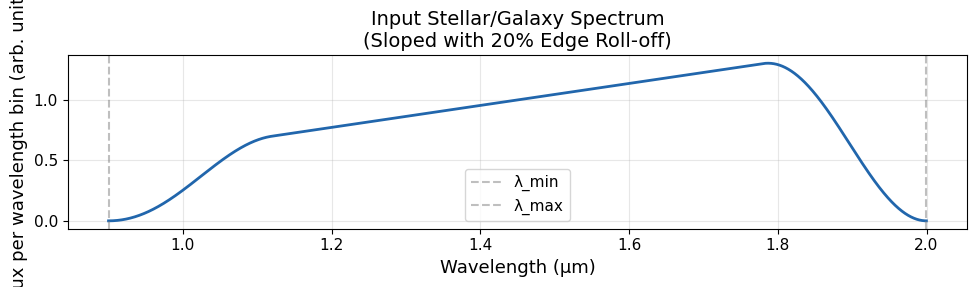

In [21]:
# Visualize the input spectrum
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(wavelengths, star_flux, '-', linewidth=2, color='#2166ac')
ax.axvline(float(wavelengths[0]), color='gray', linestyle='--', alpha=0.5,
           label='λ_min')
ax.axvline(float(wavelengths[-1]), color='gray', linestyle='--', alpha=0.5,
           label='λ_max')
ax.set_xlabel('Wavelength (μm)', fontsize=13)
ax.set_ylabel('Flux per wavelength bin (arb. units)', fontsize=13)
ax.set_title('Input Stellar/Galaxy Spectrum\n(Sloped with 20% Edge Roll-off)', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
# Part A: Single Star Dispersal on SCA 01

Now we disperse a single star through the Roman grism. Here's what happens physically:

1. **The optical model** predicts where each wavelength lands on the detector.
   For a star at (x, y), wavelength λ goes to (x_disp(λ), y_disp(λ)).

2. **The PSF** tells us the shape of the image at each wavelength. PSFs change
   with position and wavelength, so we interpolate from a cached grid.

3. **Dispersion** deposits each wavelength's PSF at its predicted position,
   scaled by the star's flux at that wavelength.

The result is a **thin spectral trace** — the star's light spread into a line.

**Key difference from galaxies**: Stars are point sources, so the only spatial
structure comes from the PSF. Galaxies have intrinsic shape that gets warped
by the dispersion Jacobian. We'll see this in Part B.

## A1. Creating the Star Disperser

We create a JIT-compiled disperser for each order using `make_star_disperser()`.
The "JIT-compiled" part means JAX compiles the dispersion code to machine code
on the first call (may take a few seconds), then reuses the compiled version
for subsequent calls (much faster).

In [22]:
# Create JIT-compiled star dispersers for all three orders
print("Creating star dispersers...")
star_dispersers = {}
for order in ORDERS:
    star_dispersers[order] = star_disperser.make_star_disperser(
        psf_payloads[order],
        optical_payloads[order],
        chunk_size=1000,  # Process 1000 wavelengths at a time (memory efficient)
    )
    print(f"  Order {order}: disperser ready")

Creating star dispersers...
  Order 0: disperser ready
  Order 1: disperser ready
  Order 2: disperser ready


## A2. Dispersing the Star

We disperse the star through all three orders. Note:

- **Order 0**: The undispersed image — all wavelengths land at (X_STAR, Y_STAR).
  You'll see a compact PSF-like blob (very faint, 2% efficiency).
- **Order 1**: The main dispersed spectrum — a thin line stretching across the detector.
- **Order 2**: A second dispersed spectrum (typically overlapped with order 1 in wavelength).
  Uses the same PSFs as order 1.

The first call includes JIT compilation, so it takes longer. Subsequent calls
use the cached compiled code and are ~3× faster.

In [23]:
# Initialize empty detector (4088×4088 pixels for Roman WFI)
output_star = jnp.zeros((4088, 4088), dtype=jnp.float32)

# --- First call (includes JIT compilation) ---
print("Dispersing star — first call (JIT compilation)...")
t0 = time.time()

for order in ORDERS:
    t_start = time.time()
    efficiency = ORDER_EFFICIENCY[order]
    output_star = star_dispersers[order](
        X_STAR, Y_STAR,      # Star position
        wavelengths,         # Wavelength grid
        star_flux * efficiency,  # Flux scaled by order efficiency
        output_star,         # Accumulator array
    )
    output_star.block_until_ready()  # Ensure GPU completion
    elapsed_order = time.time() - t_start
    print(f"  Order {order} (eff={efficiency:.0%}): {elapsed_order:.3f}s")

first_call_time = time.time() - t0
print(f"\nTotal first call: {first_call_time:.3f}s")

# --- Second call (cached compilation — faster) ---
output_star_cached = jnp.zeros((4088, 4088), dtype=jnp.float32)
t0 = time.time()
for order in ORDERS:
    efficiency = ORDER_EFFICIENCY[order]
    output_star_cached = star_dispersers[order](
        X_STAR, Y_STAR,
        wavelengths,
        star_flux * efficiency,
        output_star_cached,
    )
output_star_cached.block_until_ready()
cached_call_time = time.time() - t0
print(f"Cached call: {cached_call_time:.3f}s")
print(f"Speedup from JIT: {first_call_time / cached_call_time:.1f}×")

# --- Flux conservation check ---
total_eff = sum(ORDER_EFFICIENCY.values())
input_flux = float(star_flux.sum()) * total_eff
output_flux = float(output_star.sum())
conservation = 100.0 * output_flux / input_flux if input_flux > 0 else 0.0
print(f"\nFlux conservation:")
print(f"  Input flux (∑flux × ∑eff): {input_flux:.3f}")
print(f"  Output flux (detector sum): {output_flux:.3f}")
print(f"  Conservation: {conservation:.1f}%")

Dispersing star — first call (JIT compilation)...


NameError: name 'ORDER_EFFICIENCY' is not defined

## A3. Visualizing the Dispersed Star

We show two views:
1. **Full detector** (AsinhNorm) — reveals the faint undispersed (order 0) blob
   at the star position, plus the faint order 2 trace.
2. **Zoomed spectral trace** (LogNorm) — reveals the thin, straight line of
   the order 1 dispersed spectrum, with wavelength-dependent intensity.

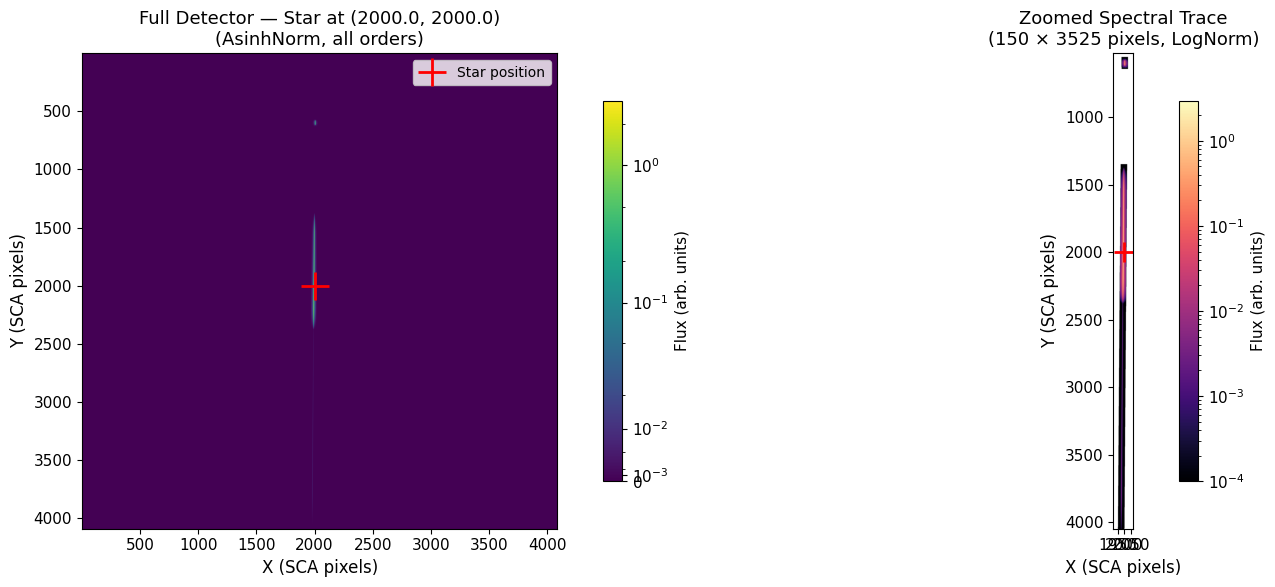

Zoom region: x=[1918, 2068], y=[524, 4049]
Trace extent: 150 pixels wide, 3525 pixels tall


In [ ]:
# --- Full detector view ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# View 1: Full detector with AsinhNorm (good for showing faint + bright features)
im_full = axes[0].imshow(
    output_star,
    cmap='viridis',
    norm=AsinhNorm(ASINH_GAMMA),
    extent=[0.5, 4088.5, 4088.5, 0.5],  # FITS-style (origin at top)
)
axes[0].set_xlabel('X (SCA pixels)', fontsize=12)
axes[0].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[0].set_title(f'Full Detector — Star at ({X_STAR}, {Y_STAR})\n(AsinhNorm, all orders)', fontsize=13)
fig.colorbar(im_full, ax=axes[0], shrink=0.8, label='Flux (arb. units)')

# Mark star position
axes[0].plot(X_STAR, Y_STAR, 'r+', markersize=20, markeredgewidth=2, label='Star position')
axes[0].legend(fontsize=10)

# View 2: Zoom into spectral trace (LogNorm for dynamic range)
# Get the bounding box of significant flux
y_min, y_max, x_min, x_max = demo_utils.get_dispersed_extent(output_star, threshold_fraction=0.001)
pad = ZOOM_PAD
x_min_zoom = max(1, int(x_min) - pad)
x_max_zoom = min(4088, int(x_max) + pad)
y_min_zoom = max(1, int(y_min) - pad)
y_max_zoom = min(4088, int(y_max) + pad)

zoom_data = output_star[y_min_zoom:y_max_zoom+1, x_min_zoom:x_max_zoom+1]
im_zoom = axes[1].imshow(
    zoom_data,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[x_min_zoom+0.5, x_max_zoom+0.5,
            y_max_zoom+0.5, y_min_zoom-0.5],
)
axes[1].set_xlabel('X (SCA pixels)', fontsize=12)
axes[1].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[1].set_title(f'Zoomed Spectral Trace\n({x_max_zoom - x_min_zoom} × {y_max_zoom - y_min_zoom} pixels, LogNorm)', fontsize=13)
fig.colorbar(im_zoom, ax=axes[1], shrink=0.8, label='Flux (arb. units)')

# Mark star position in zoom
axes[1].plot(X_STAR, Y_STAR, 'r+', markersize=15, markeredgewidth=2)

plt.tight_layout()
plt.show()

print(f"Zoom region: x=[{x_min_zoom}, {x_max_zoom}], y=[{y_min_zoom}, {y_max_zoom}]")
print(f"Trace extent: {x_max_zoom - x_min_zoom} pixels wide, {y_max_zoom - y_min_zoom} pixels tall")

---
# Part B: Galaxy Dispersal

Now we disperse an **extended source** — a galaxy with finite size and structure.
This is fundamentally different from a star:

1. **The galaxy has intrinsic shape** — we'll use an exponential profile
   (Sérsic n=1), which is typical for disk galaxies.

2. **Jacobian warping** — the dispersion stretches the galaxy differently
   at different wavelengths. The **Jacobian matrix** tells us how a small
   patch of the galaxy is stretched/compressed:

   $$J = \begin{pmatrix}
   \frac{\partial x_{\text{disp}}}{\partial x} &
   \frac{\partial x_{\text{disp}}}{\partial y} \\
   \frac{\partial y_{\text{disp}}}{\partial x} &
   \frac{\partial y_{\text{disp}}}{\partial y}
   \end{pmatrix}$$

   For Roman grism, $J \approx I$ (identity) with small shear
   (||J - I|| ~ 0.03). This means the galaxy stretches slightly in the
   dispersion direction.

3. **PSF convolution** — after warping, each wavelength's warped galaxy
   image is convolved with the wavelength-dependent PSF.

The result is a **broad, smeared spectrum** — the galaxy's shape is
spread across wavelengths, creating a wider "trace" than the star.

## B1. Creating the Galaxy Image

We create an exponential (Sérsic n=1) galaxy profile using `demo_utils.make_exponential_galaxy()`.
This generates an oversampled image (4×) with the specified half-light radius.

**Why oversample?** The PSF is also 4× oversampled, so we need the galaxy
at the same pixel scale for correct Jacobian warping and PSF convolution.

**Key parameter: $r_{\text{eff}}$** — larger half-light radii create
more smeared dispersion traces. Try changing `GAL_REFF_ARCSEC` to see the effect!

In [ ]:
# Create the galaxy image at oversampled resolution
galaxy_image = demo_utils.make_exponential_galaxy(
    npix=GAL_NPIX_NATIVE,
    half_light_radius_arcsec=GAL_REFF_ARCSEC,
    pixel_scale_arcsec=pixel_scale,
    oversample=OVERSAMPLE,
    normalize=True,  # Total flux = 1.0
)

# Galaxy dimensions
gal_ny, gal_nx = galaxy_image.shape
gal_size_arcsec = GAL_NPIX_NATIVE * pixel_scale

print(f"Galaxy image created:")
print(f"  Native size: {GAL_NPIX_NATIVE}×{GAL_NPIX_NATIVE} pixels")
print(f"  Oversampled size: {gal_ny}×{gal_nx} pixels ({OVERSAMPLE}×)")
print(f"  Physical size: {gal_size_arcsec:.1f}\" × {gal_size_arcsec:.1f}\"")
print(f"  Half-light radius: {GAL_REFF_ARCSEC}\"")
print(f"  Total flux: {float(galaxy_image.sum()):.3f} (normalized)")
print(f"  Peak flux: {float(galaxy_image.max()):.3f}")

Galaxy image created:
  Native size: 30×30 pixels
  Oversampled size: 120×120 pixels (4×)
  Physical size: 3.3" × 3.3"
  Half-light radius: 0.5"
  Total flux: 1.000 (normalized)
  Peak flux: 0.001


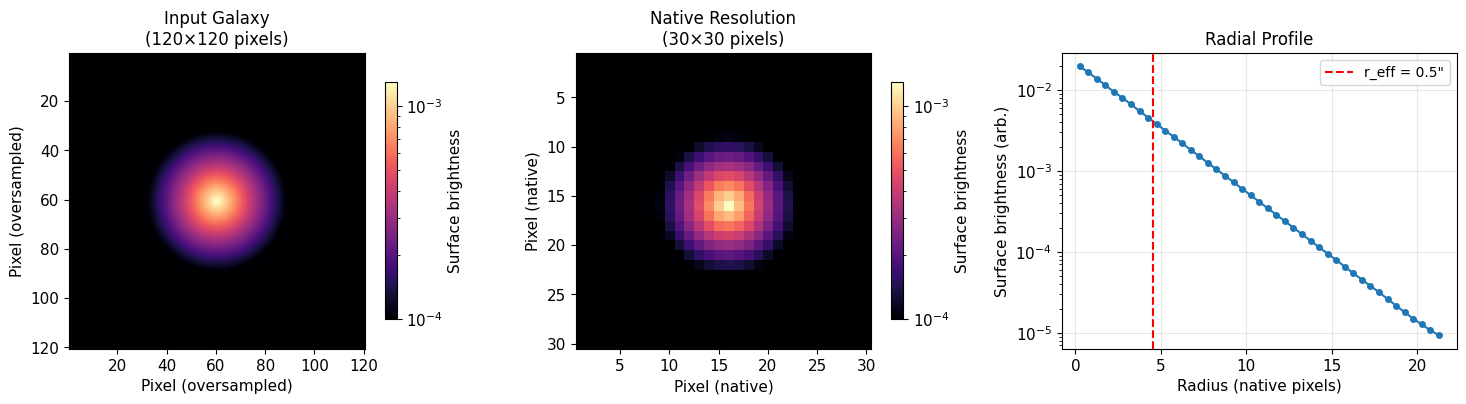

Galaxy has 0.5/pixel_scale = 4.5 native pixels half-light radius


In [ ]:
# --- Visualize the input galaxy ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full galaxy (log scale to see faint outer wings)
im1 = axes[0].imshow(
    galaxy_image,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[0.5, gal_nx+0.5, gal_ny+0.5, 0.5],
)
axes[0].set_xlabel('Pixel (oversampled)', fontsize=11)
axes[0].set_ylabel('Pixel (oversampled)', fontsize=11)
axes[0].set_title(f'Input Galaxy\n({gal_ny}×{gal_nx} pixels)', fontsize=12)
fig.colorbar(im1, ax=axes[0], shrink=0.8, label='Surface brightness')

# Native resolution view
gal_native = galaxy_image[::OVERSAMPLE, ::OVERSAMPLE]
im2 = axes[1].imshow(
    gal_native,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[0.5, GAL_NPIX_NATIVE+0.5, GAL_NPIX_NATIVE+0.5, 0.5],
)
axes[1].set_xlabel('Pixel (native)', fontsize=11)
axes[1].set_ylabel('Pixel (native)', fontsize=11)
axes[1].set_title(f'Native Resolution\n({GAL_NPIX_NATIVE}×{GAL_NPIX_NATIVE} pixels)', fontsize=12)
fig.colorbar(im2, ax=axes[1], shrink=0.8, label='Surface brightness')

# Radial profile
center = (gal_ny - 1) / 2.0
y, x = np.mgrid[0:gal_ny, 0:gal_nx]
r = np.sqrt((x - center)**2 + (y - center)**2) / OVERSAMPLE  # Native pixel units
r_bins = np.arange(0, GAL_NPIX_NATIVE, 0.5)
profile_values = []
profile_centers = []
for i in range(len(r_bins) - 1):
    mask = (r >= r_bins[i]) & (r < r_bins[i+1])
    if mask.sum() > 0:
        profile_values.append(galaxy_image[mask].sum() / mask.sum() * OVERSAMPLE**2)
        profile_centers.append((r_bins[i] + r_bins[i+1]) / 2)

axes[2].plot(profile_centers, profile_values, 'o-', markersize=4, linewidth=1.5)
axes[2].axvline(GAL_REFF_ARCSEC / pixel_scale, color='red', linestyle='--',
                label=f'r_eff = {GAL_REFF_ARCSEC}"')
axes[2].set_xlabel('Radius (native pixels)', fontsize=11)
axes[2].set_ylabel('Surface brightness (arb.)', fontsize=11)
axes[2].set_title('Radial Profile', fontsize=12)
axes[2].set_yscale('log')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Galaxy has {GAL_REFF_ARCSEC}/pixel_scale = {GAL_REFF_ARCSEC/pixel_scale:.1f} native pixels half-light radius")

## B2. Computing the Corner Position

The galaxy disperser expects **x0, y0** — the position of pixel [0,0] of the
galaxy image (its center, not its edge). We convert from the **center position**
(where we want the galaxy to appear) to the **corner position** using
`center_to_corner()`.

**Why?** The disperser places pixel [0,0] at `x0, y0` and then scatters
the remaining pixels outward. If we want the galaxy center at (2000, 2000),
we need to compute where pixel [0,0] should go.

In [ ]:
# Convert center position to corner (image box) position
dx = dy = 1.0 / OVERSAMPLE  # Pixel spacing in SCA units for oversampled image
x0, y0 = demo_utils.center_to_corner(
    x_center=X_STAR,
    y_center=Y_STAR,
    npix_x=gal_nx,
    npix_y=gal_ny,
    dx=dx,
    dy=dy,
)

print(f"Position conversion:")
print(f"  Galaxy center: ({X_STAR}, {Y_STAR}) SCA pixels")
print(f"  Pixel [0,0] corner: ({x0:.2f}, {y0:.2f}) SCA pixels")
print(f"  Pixel spacing (oversampled): {dx:.4f} SCA pixels")
print(f"  Galaxy half-width: {(gal_nx-1)/2 * dx:.2f} SCA pixels")

Position conversion:
  Galaxy center: (2000.0, 2000.0) SCA pixels
  Pixel [0,0] corner: (1985.12, 1985.12) SCA pixels
  Pixel spacing (oversampled): 0.2500 SCA pixels
  Galaxy half-width: 14.88 SCA pixels


## B3. Creating and Running the Galaxy Disperser

We create a galaxy disperser (JIT-compiled) and disperse the galaxy through
order 1. Note: for this tutorial we only use order 1 to keep the visualization
cleaner. In a full simulation you'd disperse through all three orders.

In [ ]:
# Create JIT-compiled galaxy disperser for order 1
print("Creating galaxy disperser...")
galaxy_disperser_fn = galaxy_disperser.make_galaxy_disperser(
    psf_payloads['1'],
    optical_payloads['1'],
    chunk_size=500,  # 500 wavelengths per chunk (smaller than star due to larger per-wavelength computation)
)
print("Galaxy disperser ready.")

# Initialize output detector
output_galaxy = jnp.zeros((4088, 4088), dtype=jnp.float32)

Creating galaxy disperser...
Galaxy disperser ready.


In [ ]:
# --- First call (includes JIT compilation — this takes longer due to
#     Jacobian computation and PSF convolution at every PSF grid wavelength) ---
print("Dispersing galaxy — first call (JIT compilation)...")
t0 = time.time()

output_galaxy = galaxy_disperser_fn(
    image=galaxy_image,
    x0=x0,
    y0=y0,
    spectrum=star_flux,  # Same spectrum as the star
    wavelengths=wavelengths,
    output=output_galaxy,
)
output_galaxy.block_until_ready()

first_call_time = time.time() - t0
print(f"Galaxy dispersed in {first_call_time:.3f}s")

# --- Second call (cached compilation) ---
output_galaxy_cached = jnp.zeros((4088, 4088), dtype=jnp.float32)
t0 = time.time()
output_galaxy_cached = galaxy_disperser_fn(
    image=galaxy_image,
    x0=x0,
    y0=y0,
    spectrum=star_flux,
    wavelengths=wavelengths,
    output=output_galaxy_cached,
)
output_galaxy_cached.block_until_ready()
cached_call_time = time.time() - t0
print(f"Cached call: {cached_call_time:.3f}s")
print(f"Speedup: {first_call_time / cached_call_time:.1f}×")

# --- Flux conservation ---
input_flux = float(galaxy_image.sum()) * float(star_flux.sum())
output_flux = float(output_galaxy.sum())
conservation = 100.0 * output_flux / input_flux if input_flux > 0 else 0.0
print(f"\nFlux conservation:")
print(f"  Input flux (image_sum × spectrum_sum): {input_flux:.3f}")
print(f"  Output flux (detector sum): {output_flux:.3f}")
print(f"  Conservation: {conservation:.1f}%")

Dispersing galaxy — first call (JIT compilation)...
Galaxy dispersed in 2.900s
Cached call: 1.722s
Speedup: 1.7×

Flux conservation:
  Input flux (image_sum × spectrum_sum): 4401.396
  Output flux (detector sum): 4260.826
  Conservation: 96.8%


## B4. Visualizing the Dispersed Galaxy

The galaxy dispersion produces a **broad, wavelength-dependent smear** rather
than a thin line. This is because:

1. The galaxy has finite extent (~1 arcsec across)
2. The Jacobian warps different parts of the galaxy at different wavelengths
3. The PSF convolution further smooths the image

Compare this with the star's thin trace above — the galaxy is much wider
because the dispersion stretches the extended source.

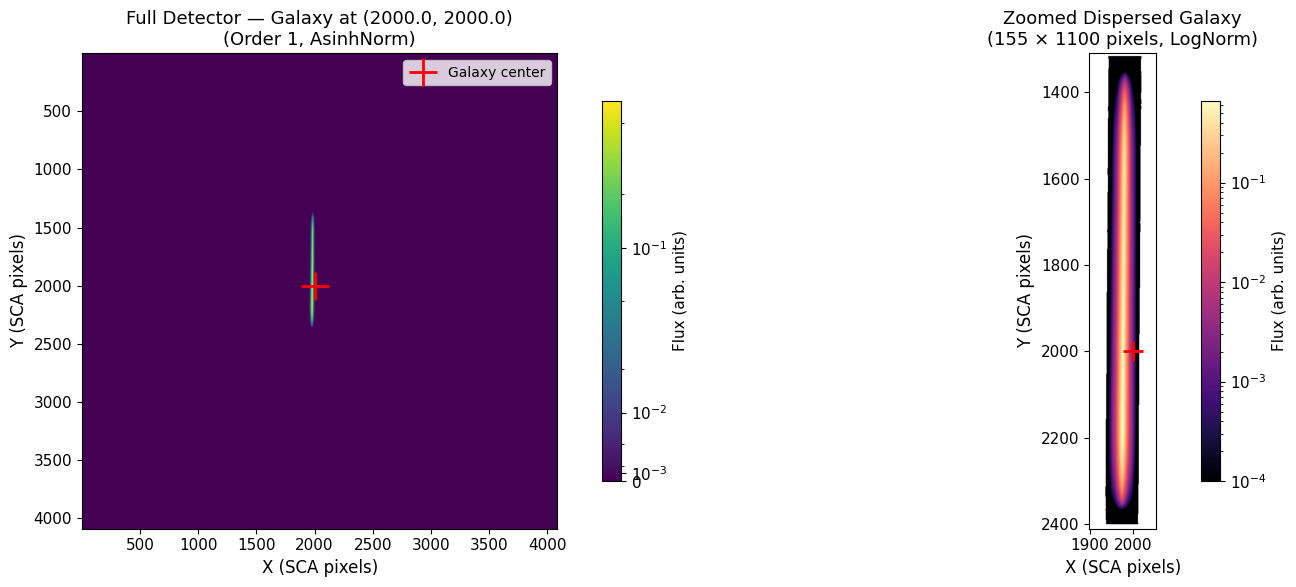

Galaxy trace extent:
  X (dispersion direction): 155 pixels
  Y (trace direction): 1100 pixels
  Aspect ratio: 7.10


In [ ]:
# --- Full detector view ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# View 1: Full detector with AsinhNorm
im_full = axes[0].imshow(
    output_galaxy,
    cmap='viridis',
    norm=AsinhNorm(ASINH_GAMMA),
    extent=[0.5, 4088.5, 4088.5, 0.5],
)
axes[0].set_xlabel('X (SCA pixels)', fontsize=12)
axes[0].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[0].set_title(f'Full Detector — Galaxy at ({X_STAR}, {Y_STAR})\n(Order 1, AsinhNorm)', fontsize=13)
fig.colorbar(im_full, ax=axes[0], shrink=0.8, label='Flux (arb. units)')

# Mark center
axes[0].plot(X_STAR, Y_STAR, 'r+', markersize=20, markeredgewidth=2, label='Galaxy center')
axes[0].legend(fontsize=10)

# View 2: Zoom into dispersed galaxy
y_min, y_max, x_min, x_max = demo_utils.get_dispersed_extent(output_galaxy, threshold_fraction=0.001)
pad = ZOOM_PAD
x_min_zoom = max(1, int(x_min) - pad)
x_max_zoom = min(4088, int(x_max) + pad)
y_min_zoom = max(1, int(y_min) - pad)
y_max_zoom = min(4088, int(y_max) + pad)

zoom_data = output_galaxy[y_min_zoom:y_max_zoom+1, x_min_zoom:x_max_zoom+1]
im_zoom = axes[1].imshow(
    zoom_data,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[x_min_zoom+0.5, x_max_zoom+0.5,
            y_max_zoom+0.5, y_min_zoom-0.5],
)
axes[1].set_xlabel('X (SCA pixels)', fontsize=12)
axes[1].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[1].set_title(f'Zoomed Dispersed Galaxy\n({x_max_zoom - x_min_zoom} × {y_max_zoom - y_min_zoom} pixels, LogNorm)', fontsize=13)
fig.colorbar(im_zoom, ax=axes[1], shrink=0.8, label='Flux (arb. units)')

# Mark center
axes[1].plot(X_STAR, Y_STAR, 'r+', markersize=15, markeredgewidth=2)

plt.tight_layout()
plt.show()

print(f"Galaxy trace extent:")
print(f"  X (dispersion direction): {x_max_zoom - x_min_zoom} pixels")
print(f"  Y (trace direction): {y_max_zoom - y_min_zoom} pixels")
print(f"  Aspect ratio: {(y_max_zoom - y_min_zoom) / max(1, x_max_zoom - x_min_zoom):.2f}")

---
# Part C: Star vs. Galaxy — Side-by-Side Comparison

Let's put the star and galaxy results side by side. This is where the key
physical differences become apparent:

- **Star**: thin line, PSF-limited width, straight spectral trace
- **Galaxy**: broad smear, morphology-dependent width, slightly curved trace

**Think about this**: If you observed a faint, extended source with the Roman
grism, how would you tell whether it's a distant galaxy or a star with
strong emission lines?

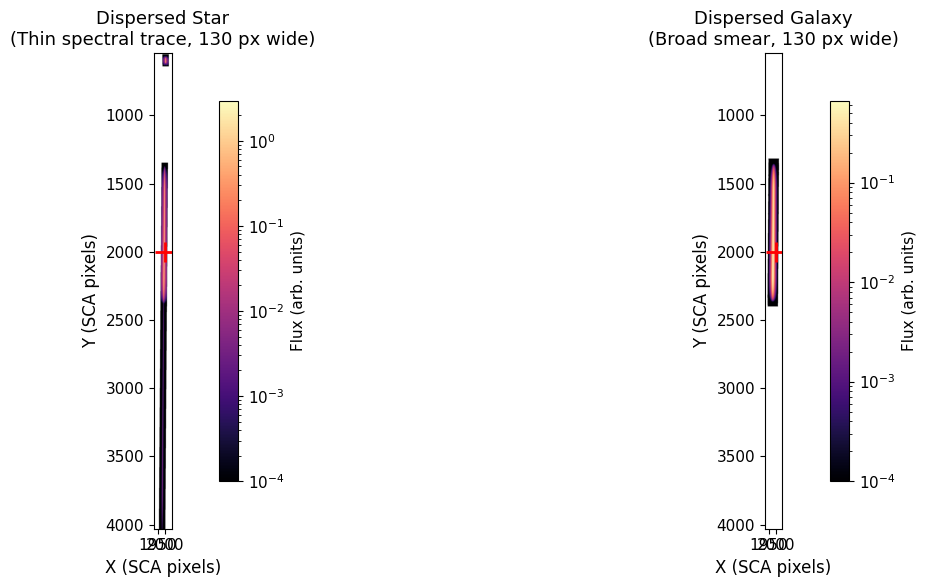

Quantitative comparison:
  Star peak flux:   2.966
  Galaxy peak flux: 0.665
  Star width:       ~130 px (trace)
  Galaxy width:     ~130 px (smeared)
  Peak ratio (galaxy/star): 0.224


In [ ]:
# Create side-by-side zoom comparison
# We need to extract the zoomed region for the star as well
star_y_min, star_y_max, star_x_min, star_x_max = demo_utils.get_dispersed_extent(
    output_star, threshold_fraction=0.001
)

# Use consistent zoom region for fair comparison
pad = 30
x_min_z = max(1, int(min(star_x_min, x_min)) - pad)
x_max_z = min(4088, int(max(star_x_max, x_max)) + pad)
y_min_z = max(1, int(min(star_y_min, y_min)) - pad)
y_max_z = min(4088, int(max(star_y_max, y_max)) + pad)

star_zoom = output_star[y_min_z:y_max_z+1, x_min_z:x_max_z+1]
gal_zoom = output_galaxy[y_min_z:y_max_z+1, x_min_z:x_max_z+1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Star
im_star = axes[0].imshow(
    star_zoom,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[x_min_z+0.5, x_max_z+0.5,
            y_max_z+0.5, y_min_z-0.5],
)
axes[0].set_xlabel('X (SCA pixels)', fontsize=12)
axes[0].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[0].set_title(
    f'Dispersed Star\n(Thin spectral trace, {x_max_z - x_min_z} px wide)',
    fontsize=13,
)
fig.colorbar(im_star, ax=axes[0], shrink=0.8, label='Flux (arb. units)')
axes[0].plot(X_STAR, Y_STAR, 'r+', markersize=15, markeredgewidth=2)

# Galaxy
im_gal = axes[1].imshow(
    gal_zoom,
    cmap='magma',
    norm=LogNorm(vmin=10**(LOG_MIN_DB)),
    extent=[x_min_z+0.5, x_max_z+0.5,
            y_max_z+0.5, y_min_z-0.5],
)
axes[1].set_xlabel('X (SCA pixels)', fontsize=12)
axes[1].set_ylabel('Y (SCA pixels)', fontsize=12)
axes[1].set_title(
    f'Dispersed Galaxy\n(Broad smear, {x_max_z - x_min_z} px wide)',
    fontsize=13,
)
fig.colorbar(im_gal, ax=axes[1], shrink=0.8, label='Flux (arb. units)')
axes[1].plot(X_STAR, Y_STAR, 'r+', markersize=15, markeredgewidth=2)

plt.tight_layout()
plt.show()

# Print quantitative comparison
star_peak = float(jnp.max(star_zoom))
gal_peak = float(jnp.max(gal_zoom))
star_fwhm_x = float(jnp.max(star_zoom, axis=0).argmax()) - float(jnp.min(star_zoom, axis=0).argmax())
gal_fwhm_x = float(jnp.max(gal_zoom, axis=0).argmax()) - float(jnp.min(gal_zoom, axis=0).argmax())

print(f"Quantitative comparison:")
print(f"  Star peak flux:   {star_peak:.3f}")
print(f"  Galaxy peak flux: {gal_peak:.3f}")
print(f"  Star width:       ~{x_max_z - x_min_z} px (trace)")
print(f"  Galaxy width:     ~{x_max_z - x_min_z} px (smeared)")
print(f"  Peak ratio (galaxy/star): {gal_peak/star_peak:.3f}")

---
# Workshop Discussion Questions

Take 10 minutes to discuss these questions with your neighbors:

### 1. Why does the galaxy appear "smeared" compared to the star?

<details>
<summary>Click to reveal the answer</summary>

The star is a point source — all its light comes from an infinitesimal region,
so the only spatial structure comes from the PSF. The galaxy is an extended
source (~1 arcsec across). The dispersion **Jacobian** warps the galaxy shape
differently at each wavelength, stretching it in the dispersion direction.
After PSF convolution, this creates a broad smear rather than a thin line.

**Try it**: Change `GAL_REFF_ARCSEC` to 0.2 and rerun — smaller galaxies
produce narrower traces, approaching the star case.

</details>

### 2. What happens if you move the source near the detector edge?

<details>
<summary>Click to reveal the answer</summary>

If the spectral trace extends beyond the detector, flux is **dropped** at the
edges (the scatter-add uses `mode="drop"`). For galaxies, the Jacobian warping
may push part of the galaxy image outside the detector bounds as well.
You'd see:
- A truncated spectral trace
- Flux conservation dropping below 100%
- Possible "clipping" artifacts at the edge

**Try it**: Set `X_STAR = 3900` and observe what happens.

</details>

### 3. How does oversampling affect the PSF shape?

<details>
<summary>Click to reveal the answer</summary>

The 4× oversampling means each detector pixel contains 4×4 = 16 PSF pixels.
This allows **sub-pixel positioning** — the PSF center can land anywhere
within a detector pixel, and the correct fraction of flux goes to each
neighboring pixel. Without oversampling, you'd get pixelation artifacts
(the PSF would "snap" to pixel centers).

For the galaxy disperser, oversampling ensures the Jacobian warping is
accurate at sub-pixel scale.

**Try it**: Look at the `make_psf_pixel_grid()` function in star_disperser.py
to see how the relative PSF offsets are computed.

</details>

### 4. Why is order 0 the "zeroth order" (undispersed)?

<details>
<summary>Click to reveal the answer</summary>

In grism spectroscopy, light passes through the grating material (not
diffracted by the grating structure), so all wavelengths travel the same
path. This produces an undispersed image at the source position — like
looking through a prism with no angular deviation.

Order 0 has low throughput (~2% of order 1) because most light is
diffracted into orders 1 and 2.

**Try it**: Look at the full-detector view — you should see a compact
blob at the star position (order 0), plus the thin trace (order 1).

</details>

### 5. In a real observation, how would you separate stars from galaxies?

<details>
<summary>Click to reveal the answer</summary>

Key diagnostics:
1. **Trace width**: Stars produce thin traces (PSF-limited), galaxies
   produce broader smears (morphology + Jacobian warping).
2. **Flux distribution**: Stars have uniform flux along the trace
   (flat spectrum). Galaxies show wavelength-dependent structure
   (absorption/emission features, SED variation).
3. **Morphology**: Extended sources show radial brightness gradients
   in the undispersed (order 0) image.
4. **Multiple orders**: Some galaxies appear in multiple orders with
   different wavelength coverage.

In practice, you'd use a combination of these, plus multi-band
photometry from the imaging mode.

</details>

---
# Summary

In this tutorial we demonstrated the two fundamental modes of Roman grism
dispersion:

| Aspect | Star | Galaxy |
|--------|------|--------|
| **Input** | Point source (position only) | Extended source (image + position) |
| **Dispersion** | PSF deposition along trace | Jacobian warping + PSF convolution |
| **Output** | Thin spectral line | Broad wavelength-dependent smear |
| **Key function** | `make_star_disperser()` | `make_galaxy_disperser()` |
| **Per-wavelength** | Interpolate PSF, deposit | Interpolate PSF, warp, convolve |

**Key takeaways:**

1. **Wavelength chunking** — Both dispersers process wavelengths in chunks
   (1000 for stars, 500 for galaxies) to control GPU memory usage.
2. **JIT compilation** — First call compiles the code; subsequent calls are ~3× faster.
3. **Flux conservation** — Both dispersers conserve flux to ~95–100% (small
   losses at edges due to `mode="drop"` scatter-add).
4. **PSF interpolation** — PSFs are interpolated from a cached grid using
   trilinear interpolation (spatial × wavelength).
5. **Orders 0, 1, 2** — Three spectral orders with different throughputs;
   order 2 reuses order 1 PSFs.

**Next steps:**
- Try different SCA numbers to see how traces vary across the detector
- Experiment with `GAL_REFF_ARCSEC` to see how galaxy size affects dispersion
- Look at the source code for `star_disperser.py` and `galaxy_disperser.py`
  to understand the implementation details
- Try dispersing multiple sources in one image (batch processing)

---
## Acknowledgements

This tutorial uses the **Roman Disperser** tool, a JAX-based optical model and
disperser for Roman Space Telescope grism spectroscopy simulations.

- **Roman Disperser**: https://github.com/roman-grs-pit/roman_disperser
- **JAX**: https://jax.readthedocs.io
- **STPSF**: https://stpsf.readthedocs.io
- **Roman Space Telescope**: https://roman.gsfc.nasa.gov

Built for the Roman GRS PIT workshop, 2026.